# Testing Noise Model On ***Bit Flip*** Error Correction Code

In [20]:
# Typical imports

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')    # Use dark background for plots

import qibo
assert qibo.__version__ >= "0.2.20", "This script requires qibo version 0.2.20 or higher."

from qibo import Circuit, gates
from qibo.result import CircuitResult
from qibo.gates import *

from qibo.ui import plot_circuit, plot_density_hist, visualize_state
from qibo.ui.drawing_utils import QIBO_COMPLEMENTARY_COLOR, QIBO_DEFAULT_COLOR, generate_bitstring_combinations

### Import QEC module ###
from qibo_qec import QEC

custom_style = {                    # Define a custom style for the circuit plot
    "facecolor" : "#000000",
    "edgecolor" : "#ffffff",
    "linecolor" : "#ffffff",
    "textcolor" : "#ffffff",
    "fillcolor" : "#c41b1b",
    "gatecolor" : "#9000ff",
    "controlcolor" : "#360000"
}

In [21]:
### Import Noise Model ###
from qibo.noise import NoiseModel, PauliError

## Compare Noise with and without Error Correction

Define noise model with Bit Flip Error as a Pauli X gate with certain error probability after an H gate

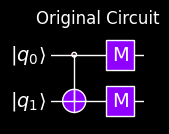

Initialized QEC with code type: bit_flip
Applying bit_flip code to a circuit with 10 qubit(s).


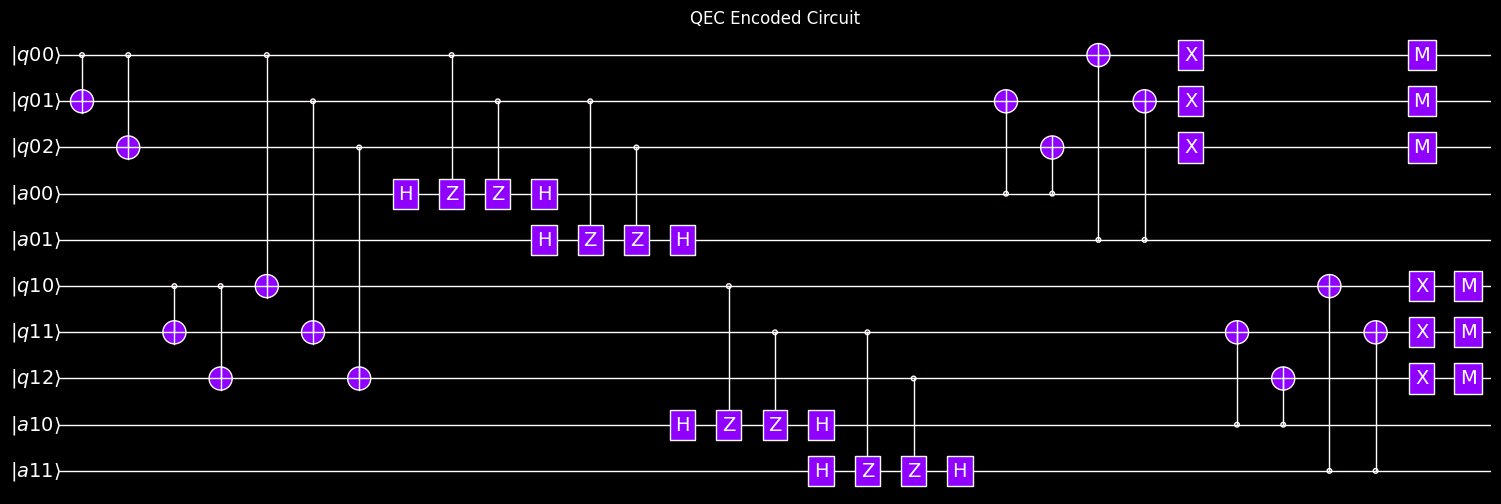

In [31]:
noise_model = NoiseModel()
noise_model.add(PauliError([("Y", 0)]), gates.H, 0) # Apply X error with 50% probability after H gate

qc = Circuit(2)
qc.add( [ gates.CNOT(0, 1)] )
qc.add( [ gates.M(0), gates.M(1) ] )

# qc = Circuit(1)
# qc.add( [ gates.H(0), gates.M(0)] )

plot_circuit(qc, style=custom_style)
plt.title("Original Circuit")
plt.show()

qec = QEC(code_type="bit_flip")
qc_qec = qec.apply_code(qc)

plot_circuit(qc_qec, style=custom_style)
plt.title("QEC Encoded Circuit")
plt.show()

Apply noise model to the circuits

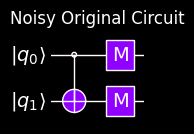

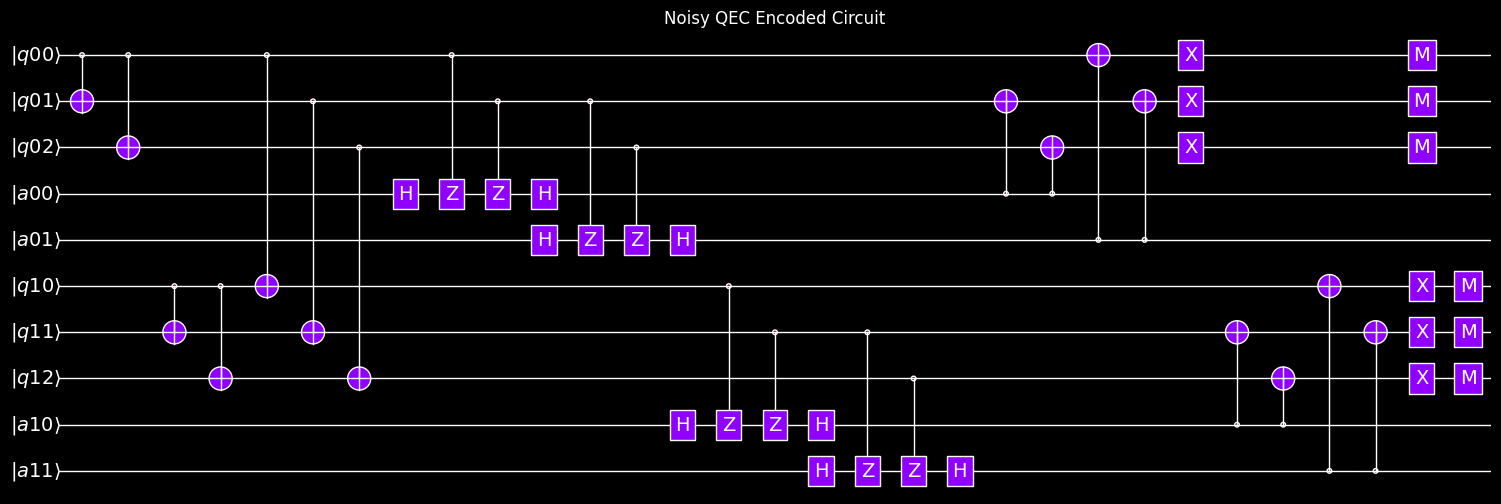

In [32]:
qc_noisy = noise_model.apply(qc)
plot_circuit(qc_noisy, style=custom_style)
plt.title("Noisy Original Circuit")
plt.show()

qc_qec_noisy = noise_model.apply(circuit=qc_qec)
plot_circuit(qc_qec_noisy, style=custom_style)
plt.title("Noisy QEC Encoded Circuit")
plt.show()

Run the noise models

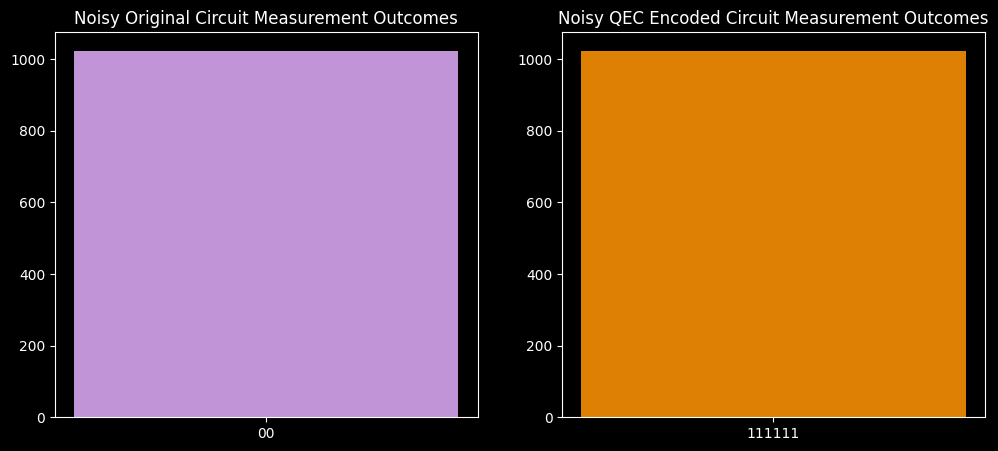

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

result = qc_noisy(nshots=2**10)
ax[0].set_title("Noisy Original Circuit Measurement Outcomes")
ax[0].bar(result.frequencies().keys(), result.frequencies().values(), color=QIBO_DEFAULT_COLOR)

result_qec = qc_qec_noisy(nshots=2**10)
ax[1].set_title("Noisy QEC Encoded Circuit Measurement Outcomes")
ax[1].bar(result_qec.frequencies().keys(), result_qec.frequencies().values(), color=QIBO_COMPLEMENTARY_COLOR)
plt.show()

## Error Treshold For Single Error Event

Let's iterate through different noise rates to see the circuit's behaviour

In [36]:
res_og = []
res_qec = []
error_rates = []
shots = 1000

for i in np.linspace(0, 0.8, 6):

    error_rates.append(round(i,2))

    noise_model = NoiseModel()
    noise_model.add(PauliError([("X", i)]), gates.CNOT, 0)

    qc_noisy = noise_model.apply(circuit=qc)
    res_og.append(qc_noisy(nshots=shots))
    
    qc_qec_noisy = noise_model.apply(circuit=qc_qec)
    res_qec.append(qc_qec_noisy(nshots=shots))

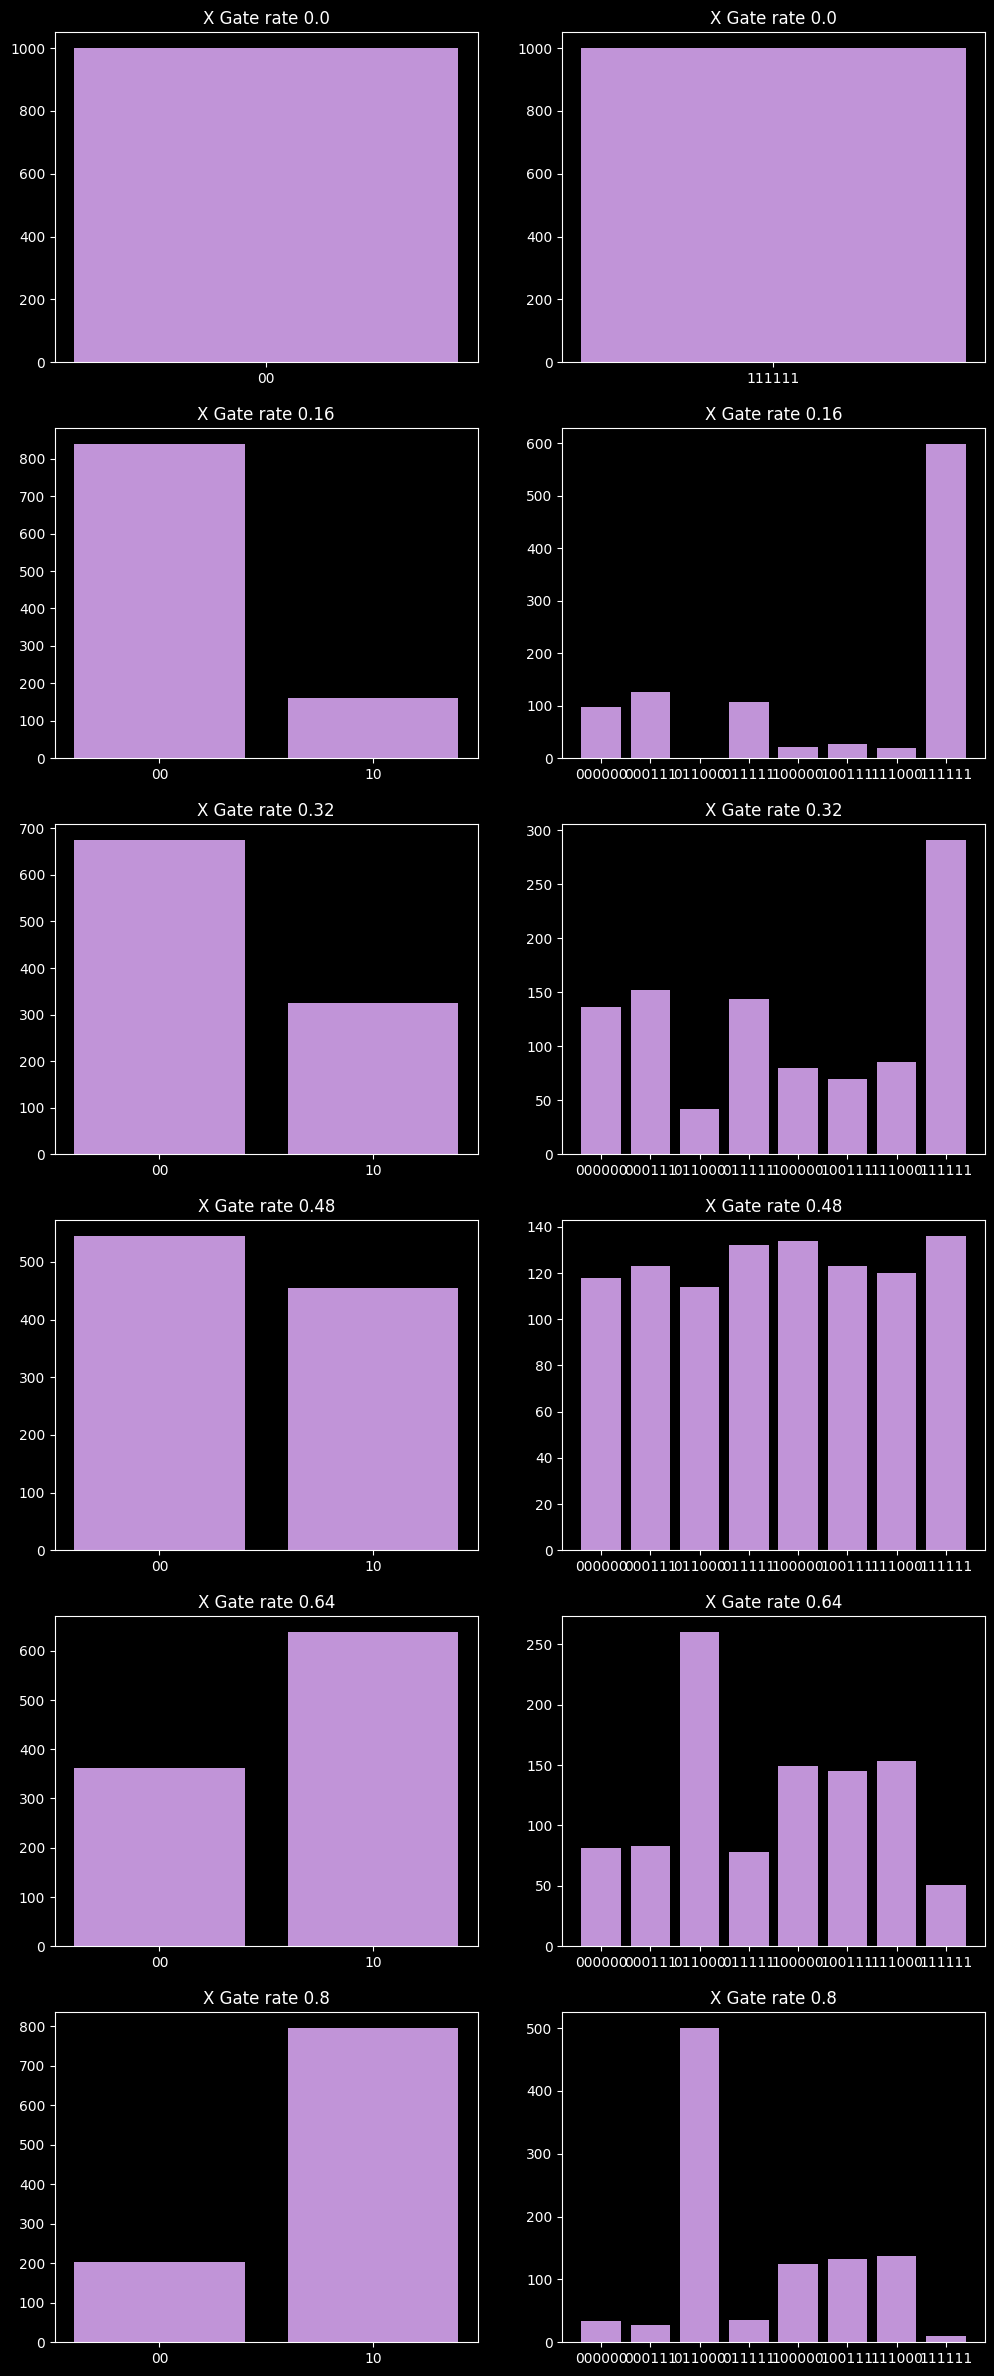

In [37]:
fig, ax = plt.subplots(len(error_rates) , 2, figsize=(12, len(error_rates)*5))

for i in range(len(error_rates)):

    ax[i, 0].bar(res_og[i].frequencies().keys(), res_og[i].frequencies().values(), color=QIBO_DEFAULT_COLOR)
    ax[i, 0].set_title(f"X Gate rate {error_rates[i]}")

    ax[i, 1].bar(res_qec[i].frequencies().keys(), res_qec[i].frequencies().values(), color=QIBO_DEFAULT_COLOR)
    ax[i, 1].set_title(f"X Gate rate {error_rates[i]}")

    rate = (res_qec[i].frequencies().get('000000',0)+res_qec[i].frequencies().get('111111',0))
    # ax[i, 1].legend([f"Coherence Rate: {round(rate/shots, 2)}"])

plt.show()